In [18]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

C:\Users\anish\AppData\Local\Temp\ipykernel_19820\4123191527.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [19]:
## Used the inbuilt tools of wikipedia

api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=250)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [20]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=250)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [21]:
tool=[wiki,arxiv]

In [22]:
## custom tools---> RAG tools

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

c:\Users\anish\Documents\LANGCHAIN\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [23]:
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1653.42it/s]


In [24]:
loader=WebBaseLoader("https://www.ibm.com/think/topics/langchain")
docs=loader.load()
splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
document=splitter.split_documents(docs)

vectordb=FAISS.from_documents(document,embeddings)
retriever=vectordb.as_retriever()

retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000195B25643D0>, search_kwargs={})

In [25]:
from langchain_core.tools import create_retriever_tool
retriever_tool=create_retriever_tool(retriever,"langsmith-search","Search any information about Langsmith")

retriever_tool.name

'langsmith-search'

In [26]:
tools=[wiki,arxiv,retriever_tool]

In [27]:
tools

[WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\anish\\Documents\\LANGCHAIN\\venv\\lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=1, lang='en', load_all_available_meta=False, doc_content_chars_max=250)),
 ArxivQueryRun(api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.arxiv.ArxivError'>, <class 'arxiv.arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.arxiv.HTTPError'>), top_k_results=1, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=250)),
 StructuredTool(name='langsmith-search', description='Search any information about Langsmith', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x00000195E10ACDC0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x00000195B2CAC700>)]

In [28]:
## Run all these tools with Agents and LLM
## Tools,LLM ---> AgentExecutor

In [29]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [41]:
from langchain_groq import ChatGroq

groq_api_key=os.getenv("GROQ_API_KEY")
hugging_face_api_key=os.getenv("HUGGINGFACEHUB_API_TOKEN")
llm=ChatGroq(groq_api_key=groq_api_key,model_name="openai/gpt-oss-safeguard-20b")

In [42]:
from langsmith import Client

client = Client()

prompt = client.pull_prompt(
    "langchain-ai/retrieval-qa-chat",
    dangerously_pull_public_prompt=True
)

print(prompt.messages)

[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context'], input_types={}, partial_variables={}, template='Answer any use questions based solely on the context below:\n\n<context>\n{context}\n</context>'), additional_kwargs={}), MessagesPlaceholder(variable_name='chat_history', optional=True), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='{input}'), additional_kwargs={})]


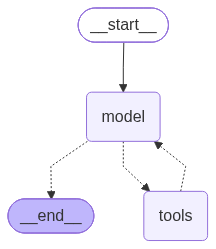

In [43]:
## Agents
from langchain.agents import create_agent

system_prompt = prompt.messages[0].prompt.template
agent=create_agent(
    model=llm,
    tools=tools,
    system_prompt=system_prompt
)
agent

In [49]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Tell me about LangSmith"}
    ]
})

In [45]:
response

{'messages': [HumanMessage(content='Tell me about LangSmith', additional_kwargs={}, response_metadata={}, id='bcf87309-711a-4866-8943-f2ac3891a40d'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to answer based on context? The context is empty. But we can use the tools. We should use langsmith-search to get info. Let's call it.", 'tool_calls': [{'id': 'fc_b36ddf3d-91ee-483a-9c36-51e9107998ea', 'function': {'arguments': '{"query":"LangSmith"}', 'name': 'langsmith-search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 287, 'total_tokens': 347, 'completion_time': 0.063492224, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.021797035, 'prompt_tokens_details': None, 'queue_time': 0.046731445, 'total_time': 0.085289259}, 'model_name': 'openai/gpt-oss-safeguard-20b', 'system_fingerprint': 'fp_b5ae46a825', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'mode

In [46]:
print(response["messages"][-1].content)

**LangSmith** is a platform built to bring production‑grade observability, debugging, and evaluation to large‑language‑model (LLM) applications. It launched in the fall of 2023 as a complement to the LangChain ecosystem, but it can be used with any LLM‑based workflow.

| Feature | What it does | Why it matters |
|---------|--------------|----------------|
| **Automatic tracing** | Every model call (prompt, response, embeddings, etc.) is captured and visualised in a timeline. | Lets developers see where latency or errors occur and compare different model versions or configurations. |
| **Evaluation tools** | Supports “LLM‑as‑a‑judge” evaluators that automatically score agent or model outputs against a set of criteria. | Enables continuous performance monitoring and quick identification of drift or sub‑optimal behavior. |
| **Debugging & metrics** | Provides dashboards for error rates, token usage, cost, and custom metrics. | Helps optimise cost‑efficiency and reliability before deployin

In [52]:
res = agent.invoke({
    "messages": [
        {"role": "user", "content": "How old the platform Wikipedia is?"}
    ]
})

In [53]:
res

{'messages': [HumanMessage(content='How old the platform Wikipedia is?', additional_kwargs={}, response_metadata={}, id='8ede6a1c-1ff9-4310-b1ae-7c40a4c2b6e2'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "How old the platform Wikipedia is?" So they want the age of Wikipedia. We need to answer based on context? The context is empty? Actually the context placeholder is {context}. But we have no context provided. So we need to use general knowledge. But maybe we should use the Wikipedia function to fetch current info. We\'ll search "Wikipedia age". But we can also answer: Wikipedia was launched in 2001, so as of 2026 it\'s about 25 years old. But we might want to verify. Let\'s call the Wikipedia function.', 'tool_calls': [{'id': 'fc_0570e479-a0ba-49fb-aa14-e9818e154cc7', 'function': {'arguments': '{"query":"Wikipedia age"}', 'name': 'wikipedia'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 289, 

In [54]:
print(res["messages"][-1].content)

Wikipedia was launched in 2001, so as of 2026 it has been around for about **25 years**.
